In [1]:
import os
import sys; sys.path.append(os.path.join(os.getcwd(), '..')); sys.path.append(os.path.join(os.getcwd(), '../helper/'));

import experiment_helper
from periodic_simulation_setup import *
import json

import parallelism, multiprocessing, itertools, setproctitle
import os, time, numpy as np

allowBending = False
useTFT = True

use_half_period = False

name = 'cosine_curve_amplitude_{}'.format('half_period' if use_half_period else 'full_period')
time_stamp = time.strftime("%Y_%m_%d_%H_%M")
# time_stamp = '2023_12_04_10_34'‰
base_folder = 'output/{}/{}'.format(name, time_stamp)
if not os.path.exists(base_folder):
    os.makedirs(base_folder)  
    
num_thread = 8
# For embarassingly parallel runs, using single thread should be more efficient
parallelism.set_max_num_tbb_threads(num_thread)

# pressure = 0.8
stiffness_pressure = 0.3
scale_factor_pressure = 0.1
avg_len = 0.2

num_experiment = 50
h = 5
amplitudes = np.linspace(0, 4.5 * (0.5 if use_half_period else 1) / h, num_experiment)

In [2]:
# Change the label number to choose different amplitude of cosine fusing curves.
label = 10
result_folder = "{}/{}".format(base_folder, label)
if not os.path.exists(result_folder):
    os.makedirs(result_folder)  

if (os.path.isfile('{}/experiment_result.json'.format(result_folder))):
    print("has {}".format(label))
print("running {}".format(label))
m, marker = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=amplitudes[label], end_threshold = 0.0, use_half_period=use_half_period)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation = 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation = 1)

fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)
print("created periodic units")
ipu = homogenized_inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)
print("start experiment")

running 10
num_seg: 25
48
created periodic units
start experiment


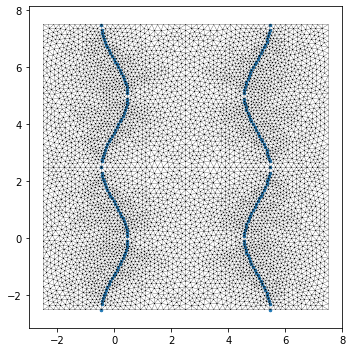

In [3]:
visualization.plot_2d_mesh(m, pointList=fusedVtx, width=5, height=5)

In [4]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [5]:
def cb(it):
    # Define a callback so it can be interrupted by the user.
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
    
disableFusedRegionTFT = False 
useTFT = True 
use_low_pressure = False 
omit_negative_curvature_escape = False 
allow_bending = True
experiment_log = {}

cr = experiment_helper.helper_run_equilibrium(ipu, allow_bending, stiffness_pressure, disableFusedRegionTFT = disableFusedRegionTFT, useTFT = useTFT, callback = cb)

experiment_log["Equilibrium energy"] = ipu.energy()

# Default to 0.
experiment_log["Negative stiffness"] = 0

if np.abs(ipu.getVars()[-2]) > 1e-7:
    # Terminate early because we cannot do stiffness analysis on a non-planar equilibrium.
    experiment_log["Ipu simulation succeed"] = int(cr.success)
    experiment_log["Planar equilibrium"] = 0
    experiment_log["Simulation Kappa value"] = (ipu.getVars()[-2])
    print("non-planar equilibrium!")
else:

    stiffness_values, sampled_alphas, stiffness_coefficient = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder, name, label, render_images = True)

    experiment_log["Min bending stiffness"] = np.min(stiffness_values)
    if np.min(stiffness_values) < 0:
        experiment_log["Negative stiffness"] = 1
        curr_vars = ipu.getVars()
        curr_vars[-1] = sampled_alphas[np.argmin(stiffness_values)]
        # Push the surface slightly out of plane to escape from the negative stiffness direction.
        curr_vars[-2] = 0.1
        ipu.setVars(curr_vars)
        # For gathering the homogenization dataset we don't really need to run this step. So we just run 100 iteration to get away from the planar configuration then stop.
        if (omit_negative_curvature_escape):
            opts.niter = 100

        bending_fixed_vars = [] if allow_bending else [ipu.numVars() - 2]
        fixedVars, hessianShift = list(periodic_unit_helper.get_center_fixedVars(ipu)) + bending_fixed_vars, hessianShiftForAlphainPlanar
        cr = inflation.inflation_newton(ipu, fixedVars, opts, callback=cb, hessianShift = hessianShift)
        experiment_log["Equilibrium energy"] = ipu.energy()
        np.save("{}/{}_dofs_after_negative_stiffness_escape_{}.npy".format(result_folder, name, variable), ipu.getVars())

    # Log and save results.
    experiment_log["Ipu simulation succeed"] = int(cr.success)
    experiment_log["Simulation Kappa value"] = (ipu.getVars()[-2])

    if np.abs(ipu.getVars()[-2]) > 1e-7:
        experiment_log["Planar equilibrium"] = 0
    else:
        experiment_log["Planar equilibrium"] = 1

    visualize_average_deformation_gradient(ipu, 100, filename = "{}/average_deformation_gradient_{}_{}.png".format(result_folder, name, label))

In [6]:
experiment_log

{'Equilibrium energy': -0.4170010163657146,
 'Negative stiffness': 0,
 'Min bending stiffness': 1.5607274141272425,
 'Ipu simulation succeed': 1,
 'Simulation Kappa value': 0.0,
 'Planar equilibrium': 1}